# Computer Vision (Image operators and filters)

By the end of this lab, you will get hands on experience working with:

*   Image Handling
*   Image Manipulation
*   Histogram and Histogram Equalization
*   Basic filtering techniques

<!-- ### **Remember this is a graded exercise.** -->

**Reminder**:

*   For every plot, make sure you provide appropriate titles, axis labels, legends, wherever applicable.
*   Add sufficient comments and explanations wherever necessary.

---


In [3]:
# Loading necessary libraries (Feel free to add new libraries if you need for any computation)

import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure, filters, io, morphology 

# Channels and color spaces

### **Exercise: Image Creation and Color Manipulation**

*   Create a 100 x 100 image for each of the below visualization

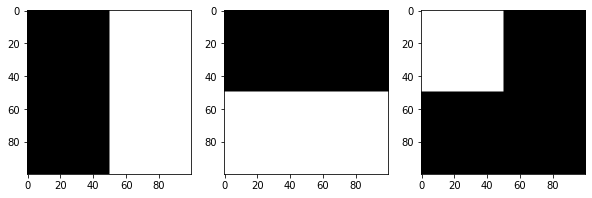

*   Visualize the created images in a 1 x 3 subplot using matplotlib.


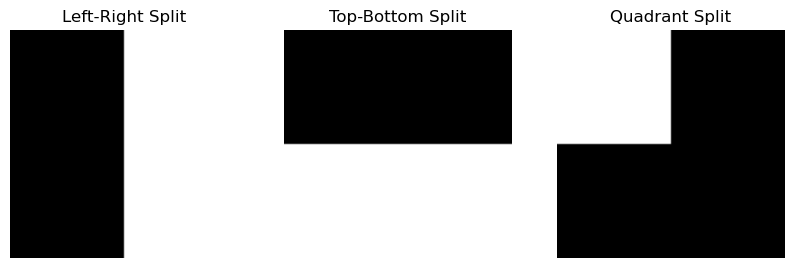

In [13]:
img1 = np.zeros((100, 100), dtype=np.uint8)
img1[:, 50:] = 255  

img2 = np.zeros((100, 100), dtype=np.uint8)
img2[50:, :] = 255  

img3 = np.zeros((100, 100), dtype=np.uint8)
img3[:50, :50] = 255  
img3[:50, 50:] = 0    
img3[50:, :50] = 0    
img3[50:, 50:] = 255  

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(img1, cmap='gray')
axes[0].axis('off')
axes[0].set_title("Left-Right Split")

axes[1].imshow(img2, cmap='gray')
axes[1].axis('off')
axes[1].set_title("Top-Bottom Split")

img3 = np.zeros((100, 100), dtype=np.uint8)

img3[:50, :50] = 255

plt.imshow(img3, cmap='gray')
plt.axis('off')
plt.title("Quadrant Split")

plt.show()

*   Use the above three images to create the following image

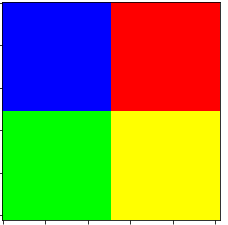
*Hint: Remember channels and color spaces*

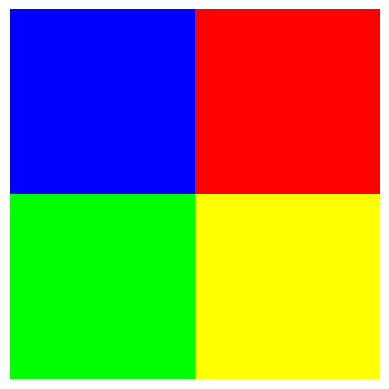

In [17]:
image = np.zeros((100, 100, 3), dtype=np.uint8)

image[:50, :50] = [0, 0, 255]   
image[:50, 50:] = [255, 0, 0]   
image[50:, :50] = [0, 255, 0]    
image[50:, 50:] = [255, 255, 0] 

plt.imshow(image)
plt.axis("off")
plt.show()


### **Exercise: Color Manipulation**

*   Read the image 'sillas.jpg' from the images folder

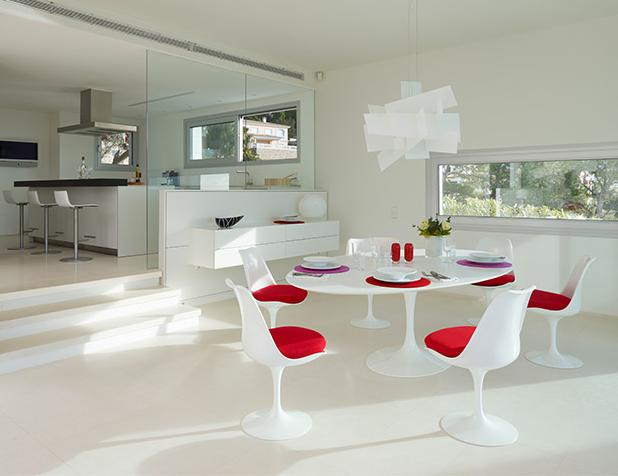

*   Extract individual channels and plot them using matplotlib subplot.



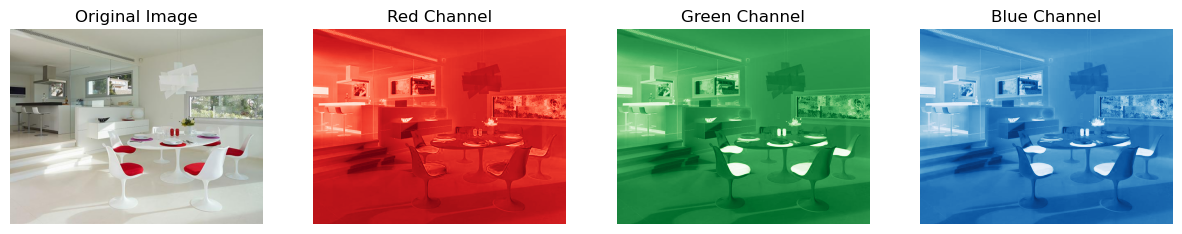

In [19]:
import cv2

image = cv2.imread('sillas.jpg')  # Ensure the image is in the correct folder
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

red_channel = image[:, :, 0]
green_channel = image[:, :, 1]
blue_channel = image[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(red_channel, cmap="Reds")
axes[1].set_title("Red Channel")
axes[1].axis("off")

axes[2].imshow(green_channel, cmap="Greens")
axes[2].set_title("Green Channel")
axes[2].axis("off")

axes[3].imshow(blue_channel, cmap="Blues")
axes[3].set_title("Blue Channel")
axes[3].axis("off")

plt.show()

*   The color **red** looks too bright for the eyes. Isn't it?? Lets change the color and see how it appears.
    *    Create a new image where everything that is **'red' is changed to 'blue'**.
*   Visualize the original image and the created image using matplotlib subplot.

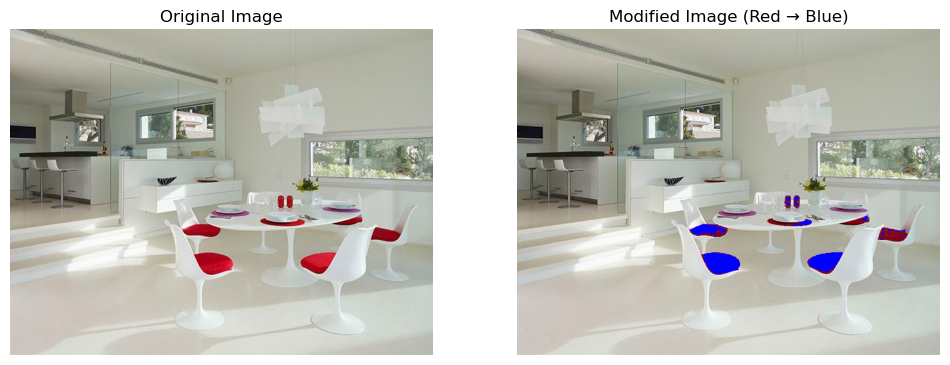

In [23]:
image = cv2.imread('sillas.jpg')  
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  

modified_image = image.copy()

lower_red = np.array([150, 0, 0])   
upper_red = np.array([255, 120, 120]) 

mask = cv2.inRange(image, lower_red, upper_red)

modified_image[mask > 0] = [0, 0, 255] 

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(modified_image)
axes[1].set_title("Modified Image (Red → Blue)")
axes[1].axis("off")

plt.show()

# Image Manipulation

### **Exercise: Image Operators**

*   You can find images 'model.png' and 'coat.png' in the images folder (First two images of the below visualization). Your task is to create an image from the given two images such a way that the model is wearing the coat (Third image in the visualization).
*   You can also find different textures in the images folder. Your task is to change the coat texture to any one of the given textures.
*   Visualize the images similar to the given visualization.

*Hint: Think masks!!!*

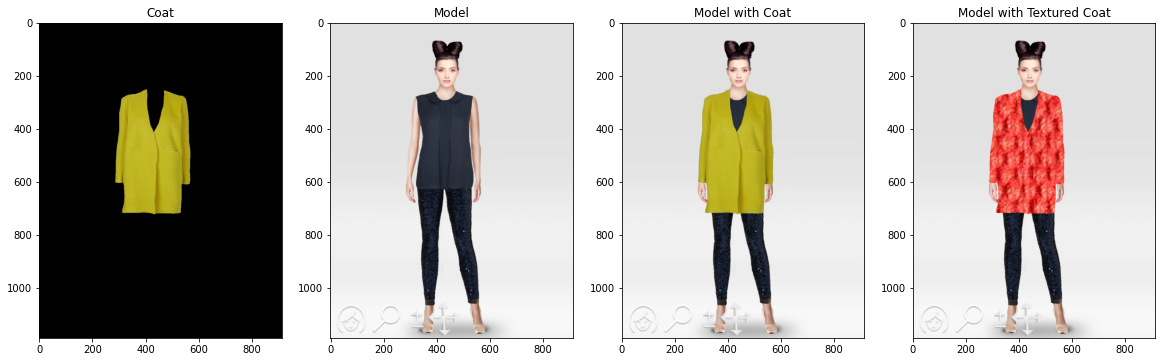

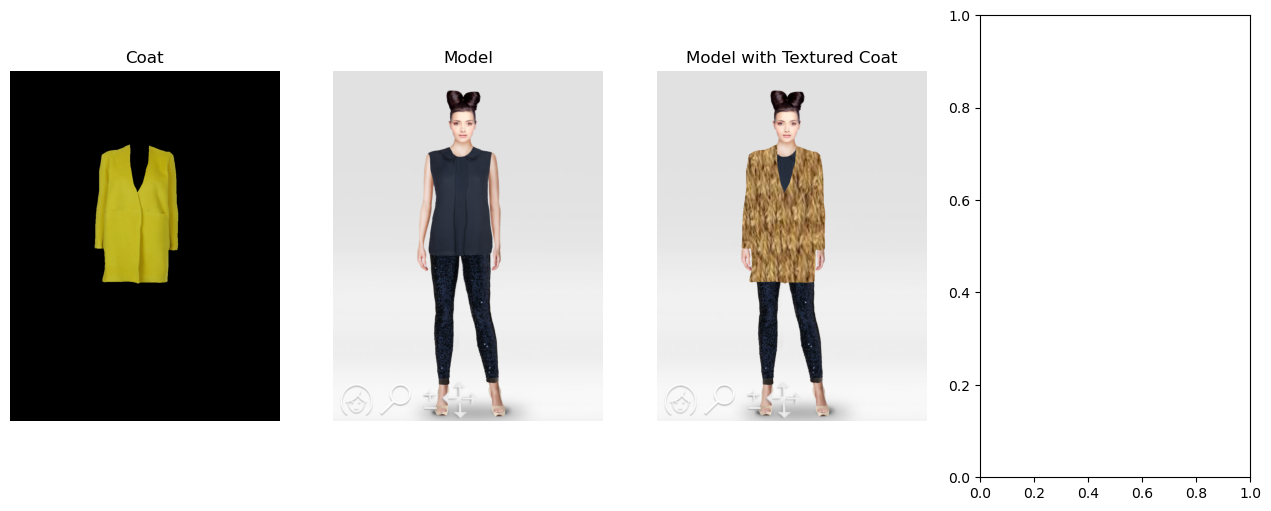

In [31]:
model = cv2.imread('model.png')   
coat = cv2.imread('coat.png')      
texture = cv2.imread('texture.png')  

model = cv2.cvtColor(model, cv2.COLOR_BGR2RGB)
coat = cv2.cvtColor(coat, cv2.COLOR_BGR2RGB)
texture = cv2.cvtColor(texture, cv2.COLOR_BGR2RGB)

gray_coat = cv2.cvtColor(coat, cv2.COLOR_RGB2GRAY)
_, mask = cv2.threshold(gray_coat, 10, 255, cv2.THRESH_BINARY)

texture = cv2.resize(texture, (coat.shape[1], coat.shape[0]))

coat_region = cv2.bitwise_and(texture, texture, mask=mask)

mask_inv = cv2.bitwise_not(mask)
model_bg = cv2.bitwise_and(model, model, mask=mask_inv)

final_image = cv2.add(model_bg, coat_region)

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

axes[0].imshow(coat)
axes[0].set_title("Coat")
axes[0].axis("off")

axes[1].imshow(model)
axes[1].set_title("Model")
axes[1].axis("off")

axes[2].imshow(final_image)
axes[2].set_title("Model with Textured Coat")
axes[2].axis("off")

plt.show()

# Contrast Enhancement

### **Exercise: Histogram Computation**

*   Read the **'astronaut' image** from data module.
*   Convert the image to grayscale.
*   Compute the **histogram of the image.** *Hint: histogram function is available in skimage.exposure package*
*   Plot the histogram using matplotlib plot.




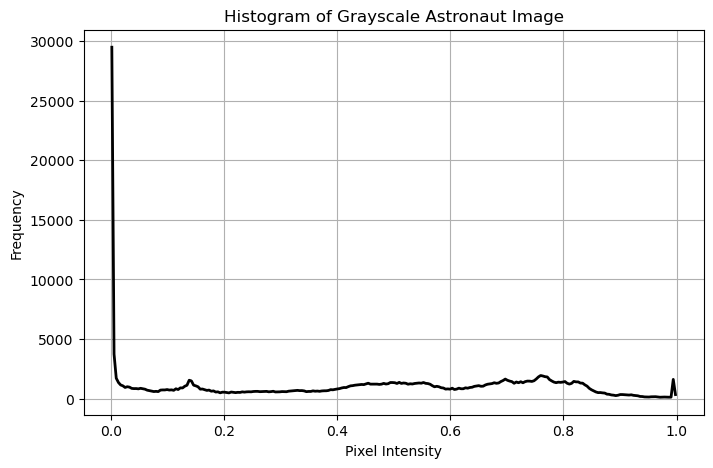

In [35]:
from skimage import data, color, exposure

image = data.astronaut()

gray_image = color.rgb2gray(image)

hist, bins = exposure.histogram(gray_image)

plt.figure(figsize=(8, 5))
plt.plot(bins, hist, color='black', lw=2)
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Histogram of Grayscale Astronaut Image')
plt.grid()
plt.show()

*   Change the bin count to 8 and compute the histogram of the image and plot the computed histogram using matplotlib plot.

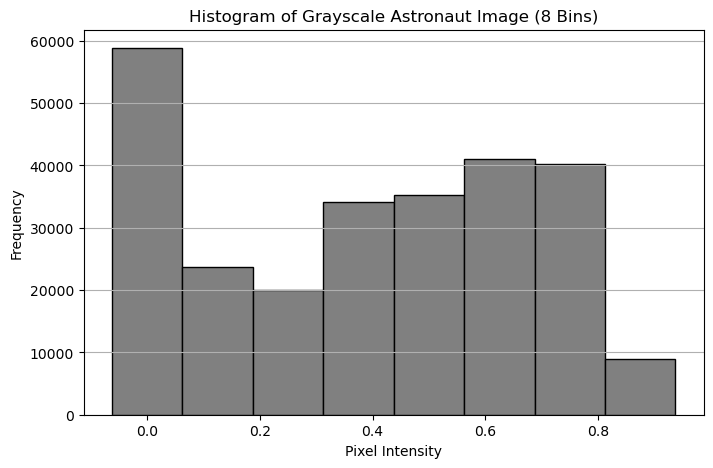

In [38]:
image = data.astronaut()

gray_image = color.rgb2gray(image)

hist, bins = np.histogram(gray_image, bins=8, range=(0, 1))

plt.figure(figsize=(8, 5))
plt.bar(bins[:-1], hist, width=(bins[1] - bins[0]), color='gray', edgecolor='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Histogram of Grayscale Astronaut Image (8 Bins)')
plt.grid(axis='y')
plt.show()



*   What happens when you change the bin count? Does your inference change based on the bin count? If yes, then how do you define the correct bin count.
*   What happens when the bin count is very low and what happens when it is very high?



**Solution**

Changing the number of bins affects how detailed or generalized the histogram appears.
Yes, the inference does change based on the bin count.
What happens when the bin count is very low? The histogram becomes less detailed
What happens When the bin count is very high? The histogram becomes very detailed


...


*   Compute histogram of the color image (without converting it to grayscale).
*   Plot the total histogram and also histogram for each channel (show it in a single plot with differnt legends for each histogram).


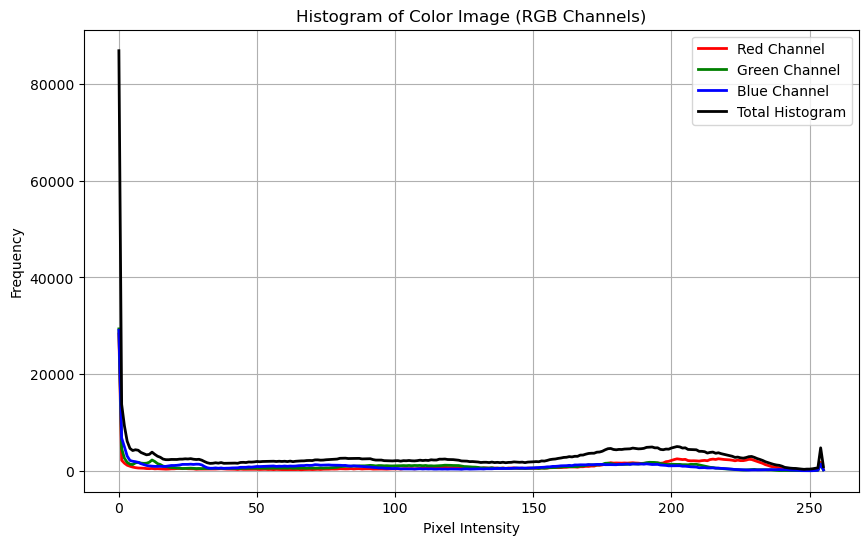

In [42]:
image = data.astronaut()

red_channel = image[:, :, 0]
green_channel = image[:, :, 1]
blue_channel = image[:, :, 2]

hist_red, bins_red = np.histogram(red_channel, bins=256, range=(0, 256))
hist_green, bins_green = np.histogram(green_channel, bins=256, range=(0, 256))
hist_blue, bins_blue = np.histogram(blue_channel, bins=256, range=(0, 256))

plt.figure(figsize=(10, 6))
plt.plot(bins_red[:-1], hist_red, color='red', label='Red Channel', lw=2)
plt.plot(bins_green[:-1], hist_green, color='green', label='Green Channel', lw=2)
plt.plot(bins_blue[:-1], hist_blue, color='blue', label='Blue Channel', lw=2)

total_hist = hist_red + hist_green + hist_blue
plt.plot(bins_red[:-1], total_hist, color='black', label='Total Histogram', lw=2)

plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Histogram of Color Image (RGB Channels)')
plt.legend()
plt.grid(True)
plt.show()


### **Exercise: Histogram Equalization**

*   Read 'aquatermi_lowcontrast.jpg' image from the images folder.
*   Compute the histogram of the image.
*   Perform histogram equalization of the image to enhance the contrast. *Hint: Use equalize_hist function available in skimage.exposure*
*   Also compute histogram of the equalized image.
*   Use 2 x 2 subplot to show the original image and the enhanced image along with the corresponding histograms.



/opt/anaconda3/lib/python3.12/site-packages/skimage/_shared/utils.py:438: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


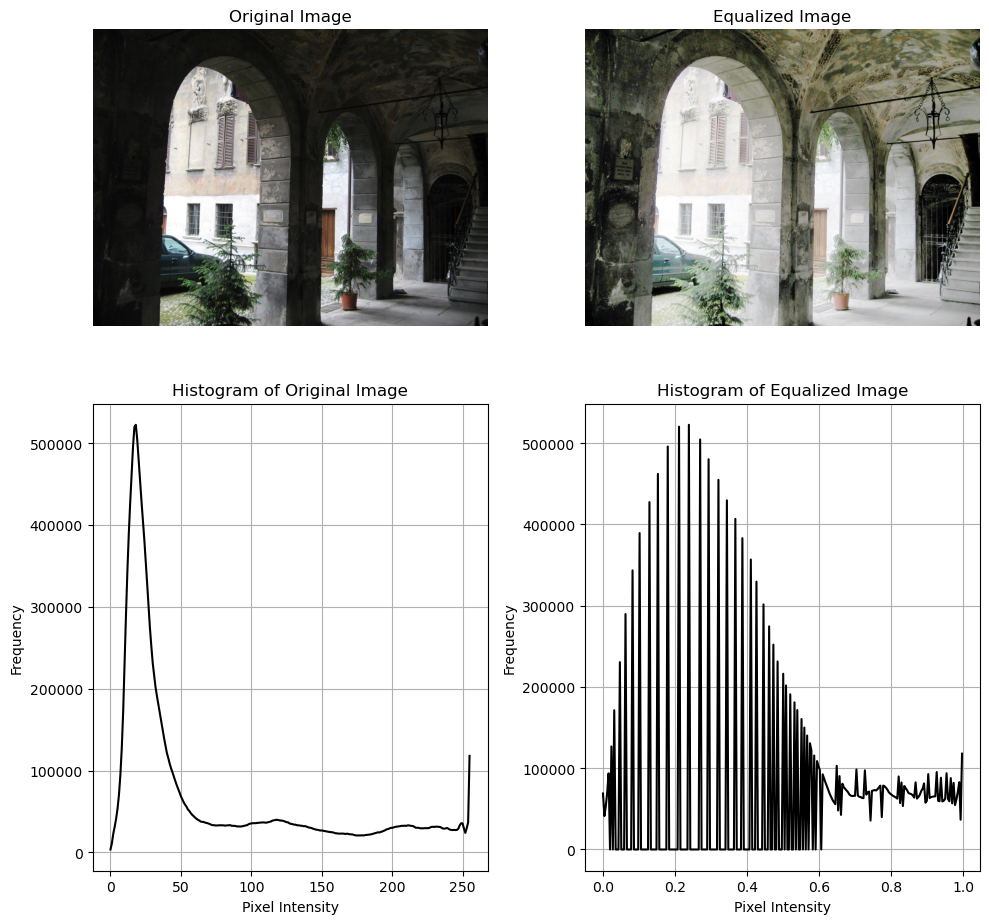

In [44]:
image = io.imread('aquatermi_lowcontrast.jpg')

hist_original, bins_original = np.histogram(image.flatten(), bins=256, range=(0, 256))

equalized_image = exposure.equalize_hist(image)

hist_equalized, bins_equalized = np.histogram(equalized_image.flatten(), bins=256, range=(0, 1))

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].axis('off')
axes[0, 0].set_title("Original Image")

axes[0, 1].imshow(equalized_image, cmap='gray')
axes[0, 1].axis('off')
axes[0, 1].set_title("Equalized Image")

axes[1, 0].plot(bins_original[:-1], hist_original, color='black')
axes[1, 0].set_title("Histogram of Original Image")
axes[1, 0].set_xlabel("Pixel Intensity")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(True)

axes[1, 1].plot(bins_equalized[:-1], hist_equalized, color='black')
axes[1, 1].set_title("Histogram of Equalized Image")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()



*   The above function in skimage.exposure uses cdf and interpolation technique to normalize the histogram. How is it different from linear contrast stretch?


**Solution**

Linear contrast stretching expands the pixel value range to cover the full range without changing the distribution, while histogram equalization uses the cumulative distribution function (CDF) to evenly distribute pixel values across the entire range, enhancing contrast more effectively.

...

### **Exercise: Linear Contrast Stretch**

*   Write a function to compute the linear contrast stretch (Do not use an inbuilt function). 
*   Provide grayscale image array and bin count as parameters to the function and return the enhanced image array.
*   Use a 2 x 2 plot to visualize the original image, histogram, enhanced image and the corresponding histogram.



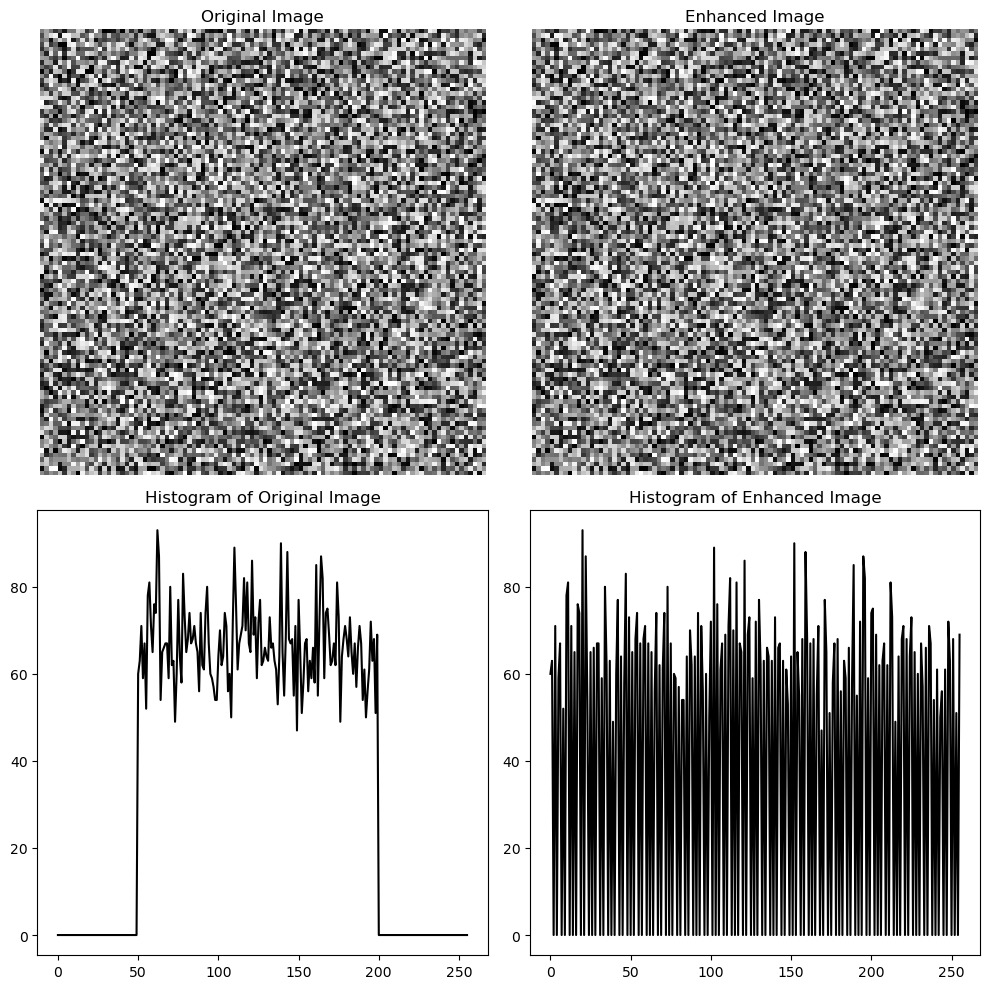

In [50]:
def linear_contrast_stretch(image):
    I_min, I_max = np.min(image), np.max(image)  
    stretched_image = (image - I_min) / (I_max - I_min) * 255  
    return stretched_image.astype(np.uint8)

def plot_image_and_histograms(original_image, enhanced_image):
    hist_original, bins_original = np.histogram(original_image.flatten(), bins=256, range=(0, 256))
    hist_enhanced, bins_enhanced = np.histogram(enhanced_image.flatten(), bins=256, range=(0, 256))

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    axes[0, 0].imshow(original_image, cmap='gray')
    axes[0, 0].axis('off')
    axes[0, 0].set_title("Original Image")

    axes[0, 1].imshow(enhanced_image, cmap='gray')
    axes[0, 1].axis('off')
    axes[0, 1].set_title("Enhanced Image")

    axes[1, 0].plot(bins_original[:-1], hist_original, color='black')
    axes[1, 0].set_title("Histogram of Original Image")

    axes[1, 1].plot(bins_enhanced[:-1], hist_enhanced, color='black')
    axes[1, 1].set_title("Histogram of Enhanced Image")

    plt.tight_layout()
    plt.show()

image = np.random.randint(50, 200, (100, 100), dtype=np.uint8)  # Create random grayscale image

enhanced_image = linear_contrast_stretch(image)

plot_image_and_histograms(image, enhanced_image)


# Filters

### **Exercise: Mean Filter**

*   Load the **coins** image from the data module.
*   Define a disk structuring element (selem) of radius 20. *Hint: Structuring elements are defined in the skimage.morphology module*
*   Use mean filter using the created selem. *Hint: The mean filter is available in skimage.filters.rank module*
*   Increase the radius of the selem by 10 and apply the mean filter.
*   Reduce the radius of the selem by 10 and apply the mean filter.
*   Visualize all the smoothened images along with the original image.




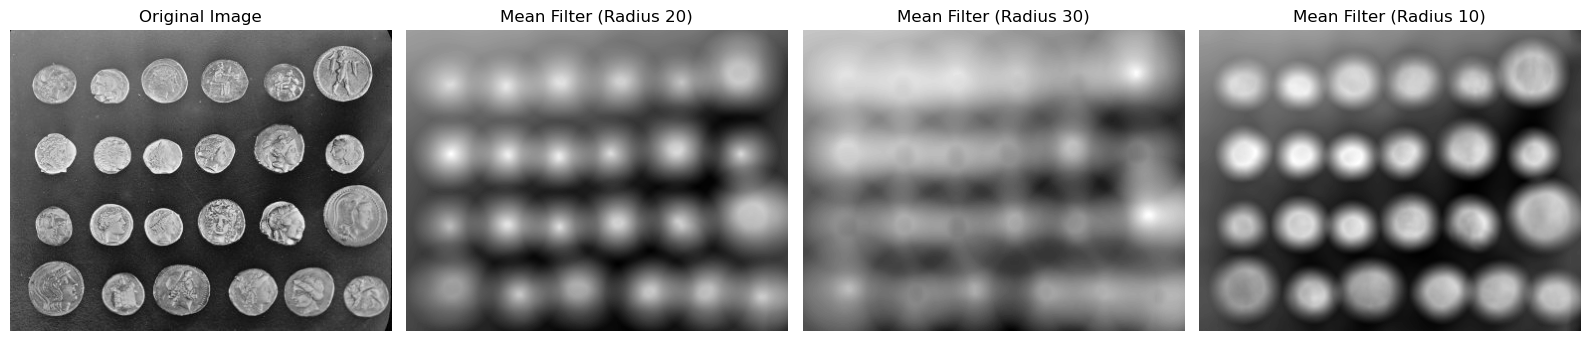

In [8]:
import matplotlib.pyplot as plt
from skimage import data, filters, morphology
from skimage.filters import rank
from skimage.morphology import disk
from skimage.util import img_as_ubyte

image = data.coins()
image = img_as_ubyte(image) 


selem1 = disk(20)  
selem2 = disk(30)  
selem3 = disk(10)  

smoothed1 = rank.mean(image, footprint=selem1)
smoothed2 = rank.mean(image, footprint=selem2)
smoothed3 = rank.mean(image, footprint=selem3)

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(smoothed1, cmap='gray')
axes[1].set_title("Mean Filter (Radius 20)")
axes[1].axis("off")

axes[2].imshow(smoothed2, cmap='gray')
axes[2].set_title("Mean Filter (Radius 30)")
axes[2].axis("off")

axes[3].imshow(smoothed3, cmap='gray')
axes[3].set_title("Mean Filter (Radius 10)")
axes[3].axis("off")

plt.tight_layout()
plt.show()


*   Use different selem (square, rectangle, star, diamond) to view the behaviour of the mean filter (It is not necessary to repeat with different sizes; it is sufficient to show the one with optimal parameter).
*   Create a 2 x n subplot to show the selem in the first row and the corresponding smoothened image in the second row.

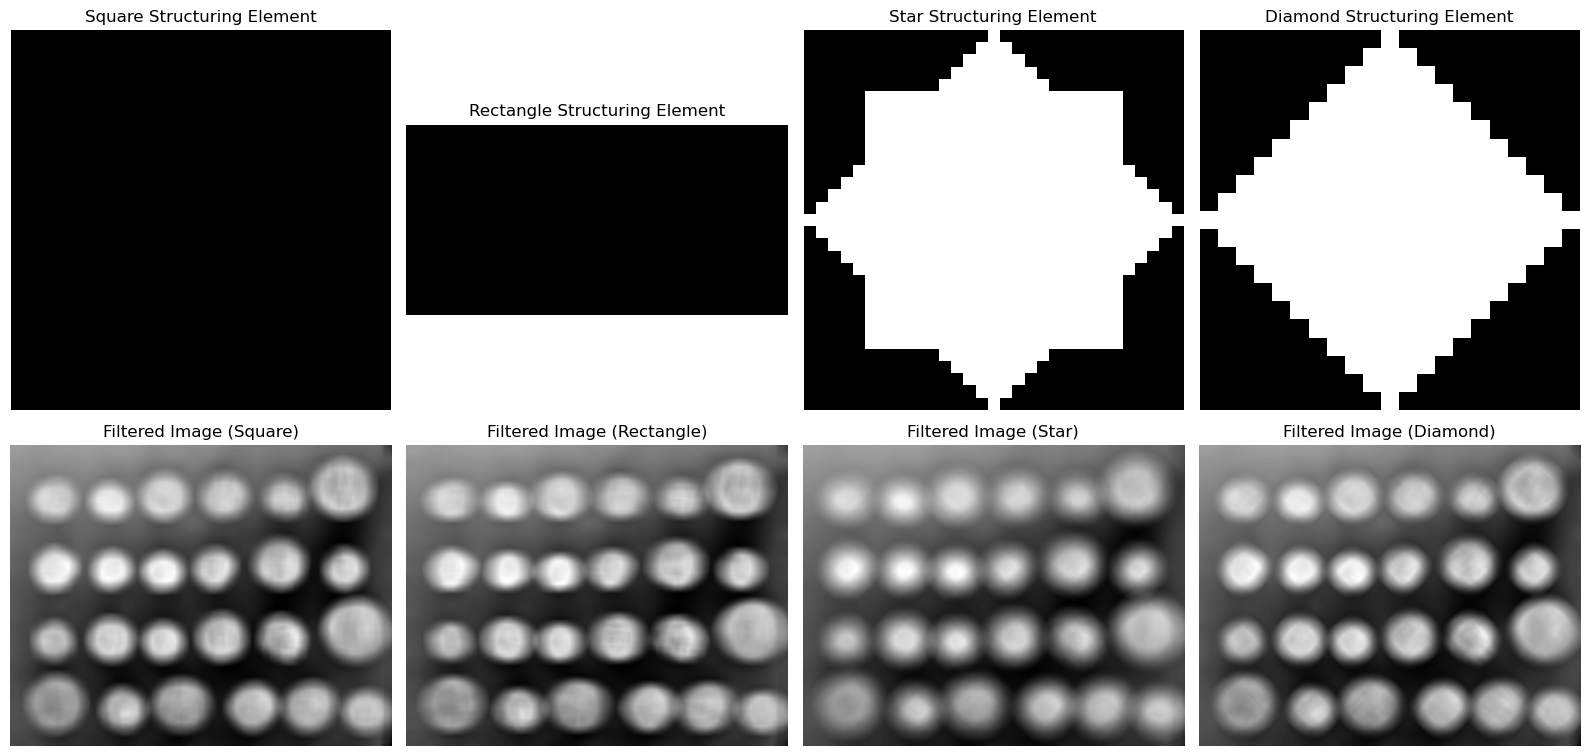

In [14]:
from skimage import data
from skimage.filters import rank
from skimage.morphology import square, rectangle, star, diamond
from skimage.util import img_as_ubyte

selem_square = square(15)
selem_rectangle = rectangle(10, 20)
selem_star = star(10)
selem_diamond = diamond(10)

filtered_square = rank.mean(image, footprint=selem_square)
filtered_rectangle = rank.mean(image, footprint=selem_rectangle)
filtered_star = rank.mean(image, footprint=selem_star)
filtered_diamond = rank.mean(image, footprint=selem_diamond)

selems = [selem_square, selem_rectangle, selem_star, selem_diamond]
filtered_images = [filtered_square, filtered_rectangle, filtered_star, filtered_diamond]
titles = ["Square", "Rectangle", "Star", "Diamond"]

fig, axes = plt.subplots(2, len(selems), figsize=(16, 8))

for i, selem in enumerate(selems):
    axes[0, i].imshow(selem, cmap='gray')
    axes[0, i].set_title(f"{titles[i]} Structuring Element")
    axes[0, i].axis("off")

for i, filtered in enumerate(filtered_images):
    axes[1, i].imshow(filtered, cmap='gray')
    axes[1, i].set_title(f"Filtered Image ({titles[i]})")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

*   How does changing the radius of disk affect the smoothing functionality?

**Solution**

Increasing the disk radius increases smoothing but reduces details, while a smaller radius preserves details with less smoothing.

...


*   What is the observed behaviour with difference in the structuring element?



**Solution**

Different structuring elements affect smoothing patterns; square and rectangle blur more uniformly, while star and diamond preserve edges better.
...



*   What is the difference between mean filter and gaussian filter?
*   Where do you use mean filters and where do you use gaussian filters?



**Solution**

The mean filter applies uniform averaging, leading to stronger blurring, while the Gaussian filter applies weighted averaging, preserving edges better. Mean filters are used for removing salt-and-pepper noise, while Gaussian filters are preferred for reducing Gaussian noise and preprocessing in vision tasks.
...